In [1]:
#As always, we start by importing the things we will need

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, EllipticalAperture, EllipticalAnnulus
from astropy.nddata import Cutout2D
from matplotlib.patches import Ellipse

In [ ]:
#Here is the general flow of today's notebook

#Use the same aperture and annulus we used for the last notebook
#Now use it to calculate errors on our measurement!
#Next, use higher resolution g-band imaging from PanSTARRS and DES, and redo the calculation!
#Next week, we will work on comparing these claculations in a plot

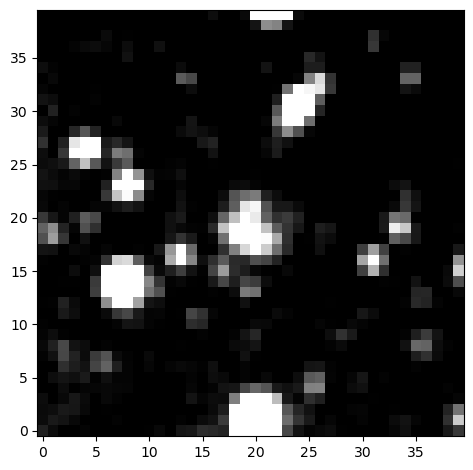

In [2]:
#Here is just copy over the same cutout cell you used in the last notebook. Should be cell 3 and look like this

hdu = fits.open('Kamino_dwarf.fits')[0]#FILL IN WITH FILEPATH!
data = hdu.data
header=hdu.header

cmap=plt.cm.Greys_r

#Since we should already have ds9 open, use that to make an estinate of position and size!

position=(890, 1601)#FILL IN
size=(40, 40)#FILL IN
cutout=Cutout2D(data, position, size)

minim=np.percentile(cutout.data, 60)
maxim=np.percentile(cutout.data, 96)


plt.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
plt.tight_layout()

plt.show()

In [3]:
#Now copy over the same aperture you used in the last notebook. Should be cell 4 and look like this

position = (19.5, 19)#FILL IN
a, b, theta = 9.5, 6.2, np.radians(-45)#FILL IN
aperture = EllipticalAperture(position, a, b, theta)

aper_overlay=Ellipse(
    xy=position,
    width=a,
    height=b,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=2,       # Thickness of the outline
    alpha=1.0          # Transparency
)

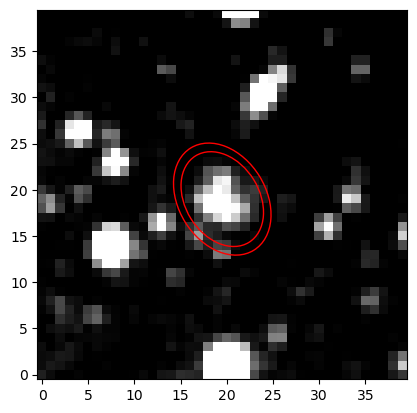

In [4]:
#Copy over the same annulus you used last time. Should be cell 5 and look like this

a_in=11
a_out=13
b_in=8
b_out=b_in*(a_out/a_in)
theta = -45

annulus = EllipticalAnnulus(position, a_in, a_out, b_out, b_in, theta)

ann_overlay_in=Ellipse(
    xy=position,
    width=a_in,
    height=b_in,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=1,       # Thickness of the outline
    alpha=1.0          # Transparency
)

ann_overlay_out=Ellipse(
    xy=position,
    width=a_out,
    height=b_out,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=1,       # Thickness of the outline
    alpha=1.0          # Transparency
)


#Let's see how this shape looks. We want to avoid stars and mostly just get blank sky
fig, ax = plt.subplots()
ax.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
#ADD THE INNER AND OUTER ANNULUS
ax.add_patch(ann_overlay_in)
ax.add_patch(ann_overlay_out)
plt.show()

In [5]:
#Okay now copy over your actual magnitude calculation. Should look like this

zp= header['ZEROPT']

phot_table = aperture_photometry(cutout.data, [aperture, annulus])

bkg_mean = phot_table['aperture_sum_1'] / annulus.area
net_flux = phot_table['aperture_sum_0'] - (bkg_mean * aperture.area)
magnitude = (-2.5 * np.log10(net_flux)) + zp

print(f"Magnitude: {magnitude[0]}")

Magnitude: 17.418985214569332


#### Nice! Now let's actually work on the new stuff, the error on the measurement

#### There are several sources of noise in astro images: Read Noise, Background fluctuation, Dark Current, and Counting Statistics to name a few. All of these noise sources get added in quadrature (if you're unfamiliar with this, it baiscally just means we square them all, add the squares, and then take the squeare root like Noise=sqrt(source1^2 + source2^2 + source3^2...)). Because of the way we add the noise, if one source is significantly larger than another, than we can essentially ignore the smaller noise. In this case, dark current and read noise can be ignored, because the counting statistics from our galaxy, and the the background fluctuations will be our biggest issues. To calculate the error, we will do the following steps
#### 1.) Find the total signal from the galaxy (what we already did to find the magnitude)
#### 2.) Find the total noise (coming from the background and counting statistics)
#### 3.) Find the signal to noise ratio (SNR: just signa/noise)
#### 4.) Convert SNR to magnitude error

In [9]:
#1.) We already completed this step. The total signal from the galaxy is just the net flux from above
gal_signal=net_flux

In [10]:
#2.) Now let's get the total noise. For this we add the background noise and the counting statistic error in quadrature
#the background error is just the square root of the total background
bkg_error=np.sqrt(bkg_mean*aperture.area)

#the counting statistics error is just the square root of the raw counts in the aperture
CS_error=np.sqrt(phot_table['aperture_sum_0'])

#Now, add these in quadrature
net_error=np.sqrt((bkg_error**2) + (CS_error**2))
print(net_error)

  aperture_sum_1  
------------------
232.52305771649765


In [11]:
#3.) finding SNR is easy, just divide the signal by the noise!
SNR= gal_signal/net_error
print(SNR[0])

0.3993659909342768


In [12]:
#4.) Lastly, we convert the SNR to a mgnitude error, to do this, we just divide 1.086 by our SNR
#This is weird and probably doesn't immediately make sense, but it's basically the result of some annoyingly complicated math
mag_err=1.086/SNR

In [13]:
#Okay! Now we can display our final magnitude with error!
print(f"Magnitude: {magnitude[0]} +/- {mag_err[0]}")

Magnitude: 17.418985214569332 +/- 2.719310168247956


### Now, to make life easier, write a function that takes in a cutout, a ZP, an aperture, and an annulus, and returns a magnitude with error

In [14]:
#write your function here!
def mag_calculation(cutout, aperture, annulus, zp):
    phot_table = aperture_photometry(cutout.data, [aperture, annulus])
    bkg_mean = phot_table['aperture_sum_1'] / annulus.area
    net_flux = phot_table['aperture_sum_0'] - (bkg_mean * aperture.area)
    magnitude = (-2.5 * np.log10(net_flux)) + zp
    gal_signal=net_flux
    bkg_error=np.sqrt(bkg_mean*aperture.area)
    #the counting statistics error is just the square root of the raw counts in the aperture
    CS_error=np.sqrt(phot_table['aperture_sum_0'])
    #Now, add these in quadrature
    net_error=np.sqrt((bkg_error**2) + (CS_error**2))
    SNR= gal_signal/net_error
    mag_err=1.086/SNR
    print(f"Magnitude: {magnitude[0]} +/- {mag_err[0]}")
    return mag_err[0], magnitude[0]

In [16]:
#test your function here!
error, mag = mag_calculation(cutout, aperture, annulus, zp)

Magnitude: 17.418985214569332 +/- 2.719310168247956


## Now let's do the same thing on higher resolution data!

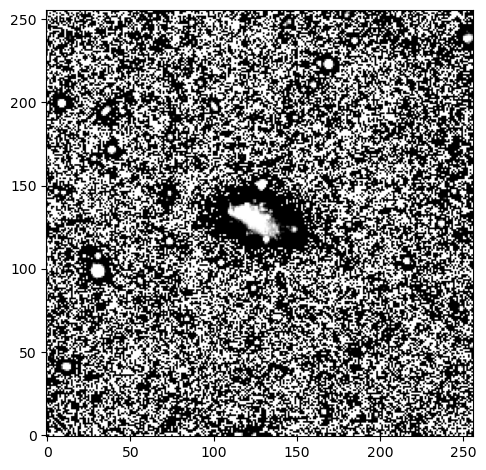

In [ ]:
#first, plot the data!
hdu = fits.open('Kamino_legacy.fits')[0]#FILL IN WITH FILEPATH!
data = hdu.data[0]
header=hdu.header

cmap=plt.cm.Greys_r

#Since we should already have ds9 open, use that to make an estinate of position and size!

cutout=data

minim=np.percentile(cutout.data, 60)
maxim=np.percentile(cutout.data, 96)


plt.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
plt.tight_layout()

plt.show()

In [ ]:
#Now make your aperture and annulus and plug them all into the function you made!
position = (126.98634, 129.36399)#FILL IN
a, b, theta = 282.8, 184.6, np.radians(-45)#FILL IN
aperture = EllipticalAperture(position, a, b, theta)

aper_overlay=Ellipse(
    xy=position,
    width=a,
    height=b,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=2,       # Thickness of the outline
    alpha=1.0          # Transparency
)

# zp = 22.5
# make anulus and then plug everything into the function!!!

In [ ]:
#Evan's function
def calc_mag_and_error(cutout, ZP, aperture, annulus, bgsub=True, ExpTime=0):
    nan_mask = ~np.isfinite(cutout)
    phot_table = aperture_photometry(cutout.data, [aperture, annulus], mask=nan_mask)
    bkg_mean = phot_table['aperture_sum_1'] / annulus.area
    if bgsub:
        net_flux = phot_table['aperture_sum_0'] - (bkg_mean * aperture.area)
    else:
        net_flux = phot_table['aperture_sum_0']
    magnitude = (-2.5 * np.log10(net_flux)) + zp + (2.5*np.log10(ExpTime))
    
    gal_signal=net_flux
    bkg_error=np.sqrt(bkg_mean*aperture.area)
    CS_error=np.sqrt(phot_table['aperture_sum_0'])
    net_error=np.sqrt((bkg_error**2)+(CS_error**2))
    SNR=gal_signal/net_error
    mag_err=1.086/SNR
    print(f"Magnitude: {magnitude[0]} +/- {mag_err[0]}")
    return magnitude[0], mag_err[0]